In [4]:
import pandas as pd
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

In [5]:
# Load the files
train_df = pd.read_csv('train.csv')
metadata_df = pd.read_csv('building_metadata.csv')

# Merge 1:
merged_df = pd.merge(train_df, metadata_df, on='building_id', how='left')

In [6]:
# Load the weather file
weather_df = pd.read_csv('weather_train.csv')

# Merge 2:
# We merge on two columns to get the weather for the right site at the right time
final_df = pd.merge(merged_df, weather_df, on=['site_id', 'timestamp'], how='left')

# You now have one complete dataset!
print(final_df.head())

   building_id  meter            timestamp  meter_reading  site_id  \
0            0      0  2016-01-01 00:00:00            0.0        0   
1            1      0  2016-01-01 00:00:00            0.0        0   
2            2      0  2016-01-01 00:00:00            0.0        0   
3            3      0  2016-01-01 00:00:00            0.0        0   
4            4      0  2016-01-01 00:00:00            0.0        0   

  primary_use  square_feet  year_built  floor_count  air_temperature  \
0   Education         7432      2008.0          NaN             25.0   
1   Education         2720      2004.0          NaN             25.0   
2   Education         5376      1991.0          NaN             25.0   
3   Education        23685      2002.0          NaN             25.0   
4   Education       116607      1975.0          NaN             25.0   

   cloud_coverage  dew_temperature  precip_depth_1_hr  sea_level_pressure  \
0             6.0             20.0                NaN              10

In [7]:
# Example: Forward-fill temperature
final_df['air_temperature'] = final_df['air_temperature'].ffill()

# Example: Fill missing year with the median year
final_df['year_built'] = final_df['year_built'].fillna(final_df['year_built'].median())

In [8]:
# Convert timestamp column to datetime objects
final_df['timestamp'] = pd.to_datetime(final_df['timestamp'])

# Create new features
final_df['hour'] = final_df['timestamp'].dt.hour
final_df['day_of_week'] = final_df['timestamp'].dt.dayofweek
final_df['month'] = final_df['timestamp'].dt.month

In [9]:
# Use One-Hot Encoding for 'primary_use'
final_df = pd.get_dummies(final_df, columns=['primary_use'])

In [10]:
final_df.isnull()

,building_id,meter,timestamp,meter_reading,site_id,square_feet,year_built,floor_count,air_temperature,cloud_coverage,...,primary_use_Office,primary_use_Other,primary_use_Parking,primary_use_Public services,primary_use_Religious worship,primary_use_Retail,primary_use_Services,primary_use_Technology/science,primary_use_Utility,primary_use_Warehouse/storage
0,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20216095,False,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
20216096,False,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
20216097,False,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
20216098,False,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


In [11]:
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype

        if col_type != 'object' and col_type != 'datetime64[ns]':
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    return df

# Run this AFTER merging and BEFORE feature engineering
# (Note: You'll need to import numpy as np)
final_df = reduce_mem_usage(final_df)

In [12]:
# --- 1. Lag Features ---
# Make sure your DataFrame is sorted by time for this to work correctly!
final_df = final_df.sort_values(['building_id', 'timestamp'])

print("Creating lag features...")
final_df['meter_reading_lag1'] = final_df.groupby('building_id')['meter_reading'].shift(1)
final_df['meter_reading_lag24'] = final_df.groupby('building_id')['meter_reading'].shift(24)

# --- 2. Weather Interaction Features ---
print("Creating HDD/CDD features...")
comfort_base_heating = 18  # degrees C
comfort_base_cooling = 21  # degrees C
final_df['hdd'] = (comfort_base_heating - final_df['air_temperature']).clip(lower=0)
final_df['cdd'] = (final_df['air_temperature'] - comfort_base_cooling).clip(lower=0)

# --- 3. Cyclical Features ---
print("Creating cyclical time features...")
final_df['hour_sin'] = np.sin(2 * np.pi * final_df['hour'] / 24.0)
final_df['hour_cos'] = np.cos(2 * np.pi * final_df['hour'] / 24.0)
final_df['day_of_week_sin'] = np.sin(2 * np.pi * final_df['day_of_week'] / 7.0)
final_df['day_of_week_cos'] = np.cos(2 * np.pi * final_df['day_of_week'] / 7.0)

# --- 4. Clean Up ---
print("Dropping original time columns...")
final_df = final_df.drop(columns=['hour', 'day_of_week'])

Creating lag features...
Creating HDD/CDD features...
Creating cyclical time features...
Dropping original time columns...


In [13]:
# --- HANDLE REMAINING NaNs ---
print("Filling remaining NaNs...")
weather_cols = ['cloud_coverage', 'dew_temperature', 'precip_depth_1_hr',
                'sea_level_pressure', 'wind_direction', 'wind_speed']

# Your fix for the ffill() error
final_df[weather_cols] = final_df[weather_cols].astype('float32')
final_df[weather_cols] = final_df[weather_cols].ffill()
final_df[weather_cols] = final_df[weather_cols].fillna(0)

# --- ⬇️ ADD THIS NEW LINE ⬇️ ---
# The new lag features will have NaNs at the start, fill them with 0
lag_cols = ['meter_reading_lag1', 'meter_reading_lag24']
final_df[lag_cols] = final_df[lag_cols].fillna(0)

# Drop any rows that *still* have NaNs (e.g., in 'meter_reading')
final_df = final_df.dropna()

Filling remaining NaNs...


In [14]:
# Transform the target variable
final_df['meter_reading'] = np.log1p(final_df['meter_reading'])

In [15]:
# The column we want to predict
target = 'meter_reading'

# Columns to drop (they are IDs, raw time, or the target itself)
cols_to_drop = [target, 'timestamp', 'building_id', 'site_id']

# 'X' is everything else
X = final_df.drop(columns=cols_to_drop)

# 'y' is just the target
y = final_df[target]

In [17]:
from sklearn.model_selection import train_test_split

# Calculate the split point (80% of the data)
split_index = int(len(X) * 0.8)

# Split the data
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (2805546, 36)
Testing data shape: (701387, 36)


In [18]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

# 2. Fit *only* on the training data
scaler.fit(X_train)

# 3. Transform both train and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

LGBM Categorical features: ['month', 'primary_use_Education', 'primary_use_Entertainment/public assembly', 'primary_use_Food sales and service', 'primary_use_Healthcare', 'primary_use_Lodging/residential', 'primary_use_Manufacturing/industrial', 'primary_use_Office', 'primary_use_Other', 'primary_use_Parking', 'primary_use_Public services', 'primary_use_Religious worship', 'primary_use_Retail', 'primary_use_Services', 'primary_use_Technology/science', 'primary_use_Utility', 'primary_use_Warehouse/storage']
Starting LightGBM training...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.154403 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2113
[LightGBM] [Info] Number of data points in the train set: 2805546, number of used features: 32
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightG

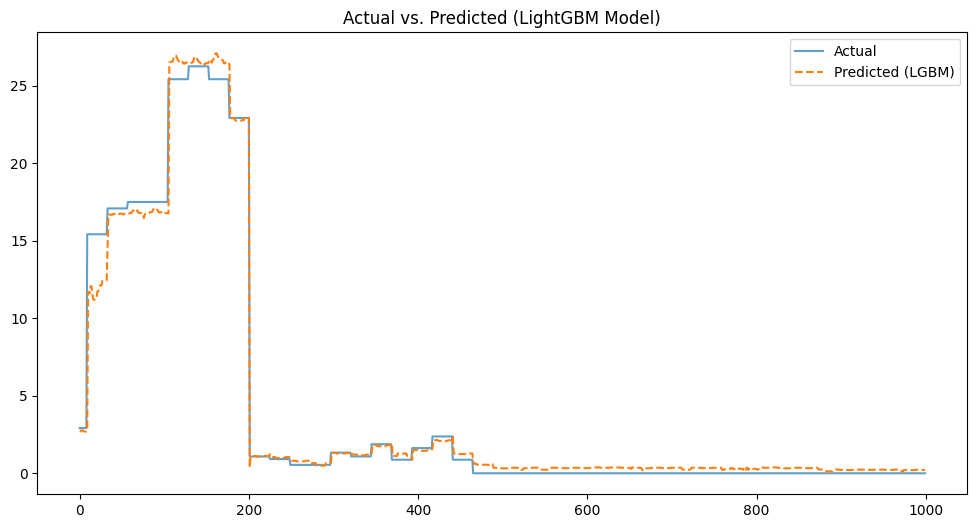

In [20]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Data and Categorical Features ---
# We use the *unscaled* X_train and X_test dataFrames
# y_train and y_test are still the log-transformed targets

# Find all your categorical feature names
categorical_features = ['month'] # We dropped 'hour' and 'day_of_week'

# Add the new sin/cos features (LGBM can treat them as categories or numbers)
# Let's add them as-is for now.

# Add all the one-hot encoded 'primary_use_' columns
primary_use_cols = [col for col in X_train.columns if 'primary_use_' in col]
categorical_features.extend(primary_use_cols)

print(f"LGBM Categorical features: {categorical_features}")

# --- 2. Create LightGBM Datasets ---
lgb_train = lgb.Dataset(X_train, y_train,
                        categorical_feature=categorical_features,
                        free_raw_data=False)

lgb_val = lgb.Dataset(X_test, y_test,
                      reference=lgb_train,
                      categorical_feature=categorical_features,
                      free_raw_data=False)

# --- 3. Set Parameters ---
params = {
    'objective': 'regression_l1',  # MAE is robust to outliers
    'metric': 'mae',
    'n_estimators': 2000,          # High number, but early stopping will find the best
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'boosting_type': 'gbdt',
    'n_jobs': -1,
    'seed': 42,
}

# --- 4. Train the Model ---
print("Starting LightGBM training...")

model_lgb = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_train, lgb_val],
    callbacks=[
        lgb.early_stopping(100),  # Stop after 100 rounds of no improvement
        lgb.log_evaluation(period=100)
    ]
)

print("Training finished.")

# --- 5. Evaluate the Results ---
print("Plotting LGBM predictions...")
predictions_lgb = model_lgb.predict(X_test, num_iteration=model_lgb.best_iteration)

# Reverse the log-transform
original_y_test = np.expm1(y_test)
predicted_y_lgb = np.expm1(predictions_lgb)
predicted_y_lgb[predicted_y_lgb < 0] = 0

# Plot the first 1000 predictions
plt.figure(figsize=(12, 6))
plt.plot(original_y_test.values[:1000], label='Actual', alpha=0.7)
plt.plot(predicted_y_lgb[:1000], label='Predicted (LGBM)', linestyle='--')
plt.title('Actual vs. Predicted (LightGBM Model)')
plt.legend()
plt.show()

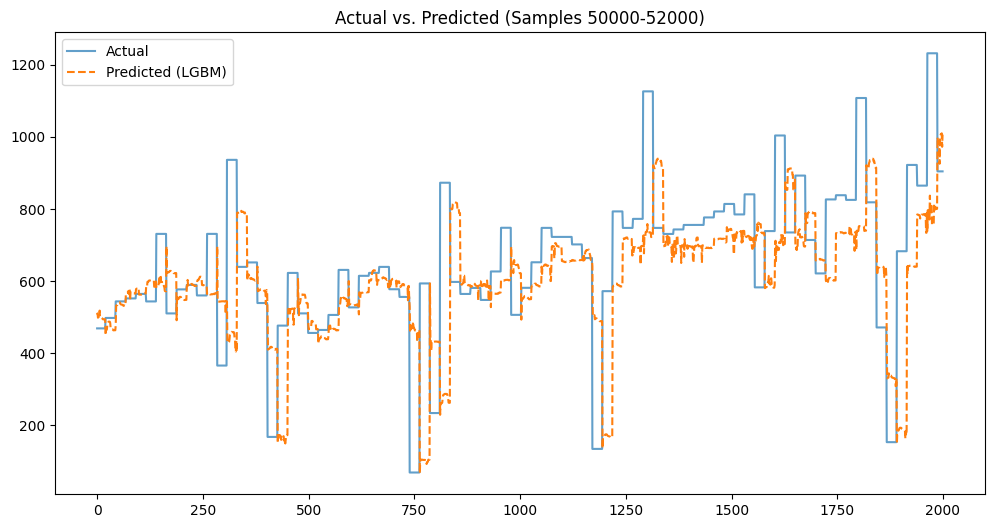

In [21]:
# --- Plot a different slice of the test data ---
# Let's plot 2000 samples, starting from sample 50,000
start_index = 50000
end_index = 52000

plt.figure(figsize=(12, 6))
plt.plot(original_y_test.values[start_index:end_index], label='Actual', alpha=0.7)
plt.plot(predicted_y_lgb[start_index:end_index], label='Predicted (LGBM)', linestyle='--')
plt.title(f'Actual vs. Predicted (Samples {start_index}-{end_index})')
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate MAE on the *original* data
final_mae = mean_absolute_error(original_y_test, predicted_y_lgb)
print(f"Final Model MAE (on original energy scale): {final_mae:.2f}")

# Calculate R2 Score
final_r2 = r2_score(original_y_test, predicted_y_lgb)
print(f"Final Model R-squared (R2 Score): {final_r2:.4f}")

Final Model MAE (on original energy scale): 237.98
Final Model R-squared (R2 Score): 0.0367


In [23]:
# Plot the top 20 most important features
lgb.plot_importance(
    model_lgb,
    figsize=(10, 8),
    max_num_features=20,
    importance_type='gain'  # 'gain' shows the total contribution to the model
)
plt.title("LightGBM Feature Importance (Top 20)")
plt.show()

ImportError: You must install matplotlib and restart your session to plot importance.

In [24]:
import joblib

# --- 1. Save the LightGBM model ---
# Use the built-in save_model method, it's very efficient
model_lgb.save_model('lgbm_model.txt')

# --- 2. Save the list of feature names ---
# Your application will need to know the *exact* column order
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

# --- 3. Save the list of categorical features ---
# The model also needs to know which features are categorical
joblib.dump(categorical_features, 'categorical_features.pkl')

print("Model and feature lists saved successfully!")

Model and feature lists saved successfully!


In [29]:
from xgboost import XGBRegressor
import time

print("Starting XGBoost training...")

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',   # fast
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

xgb_time = time.time() - start_time

print(f"XGBoost training finished in {xgb_time:.2f} seconds")

Starting XGBoost training...
[0]	validation_0-rmse:1.97254
[100]	validation_0-rmse:1.25117
[200]	validation_0-rmse:1.29949
[300]	validation_0-rmse:1.32568
[400]	validation_0-rmse:1.35281
[500]	validation_0-rmse:1.37464
[600]	validation_0-rmse:1.39370
[700]	validation_0-rmse:1.40819
[800]	validation_0-rmse:1.42628
[900]	validation_0-rmse:1.43265
[999]	validation_0-rmse:1.44615
XGBoost training finished in 185.97 seconds


In [30]:
# XGBoost predictions
predictions_xgb = xgb_model.predict(X_test)

# Reverse log-transform
predicted_y_xgb = np.expm1(predictions_xgb)
predicted_y_xgb[predicted_y_xgb < 0] = 0

In [31]:
from sklearn.metrics import mean_absolute_error, r2_score

# XGBoost metrics
xgb_mae = mean_absolute_error(original_y_test, predicted_y_xgb)
xgb_r2 = r2_score(original_y_test, predicted_y_xgb)

print(f"XGBoost MAE: {xgb_mae:.2f}")
print(f"XGBoost R2: {xgb_r2:.4f}")

XGBoost MAE: 274.28
XGBoost R2: -0.0026


In [32]:
results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost"],
    "MAE": [final_mae, xgb_mae],
    "R2 Score": [final_r2, xgb_r2],
    "Training Time (s)": ["Not Tracked", xgb_time]
})

print("\nModel Comparison:")
print(results)


Model Comparison:
      Model         MAE  R2 Score Training Time (s)
0  LightGBM  237.981155  0.036749       Not Tracked
1   XGBoost  274.279053 -0.002570        185.970559


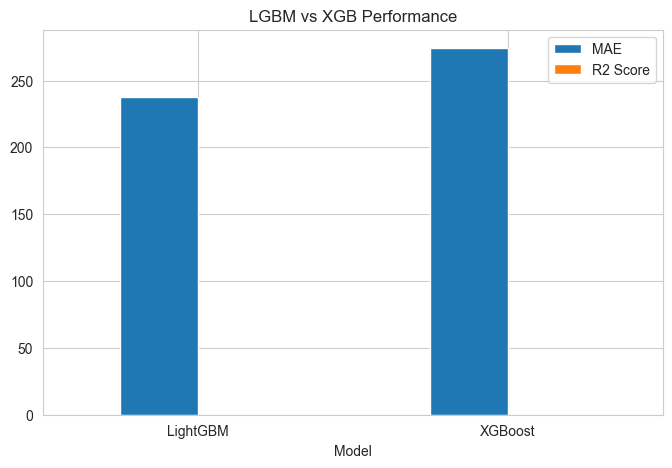

In [33]:
results_plot = results.set_index("Model")[["MAE", "R2 Score"]]

results_plot.plot(kind="bar", figsize=(8,5))
plt.title("LGBM vs XGB Performance")
plt.xticks(rotation=0)
plt.show()

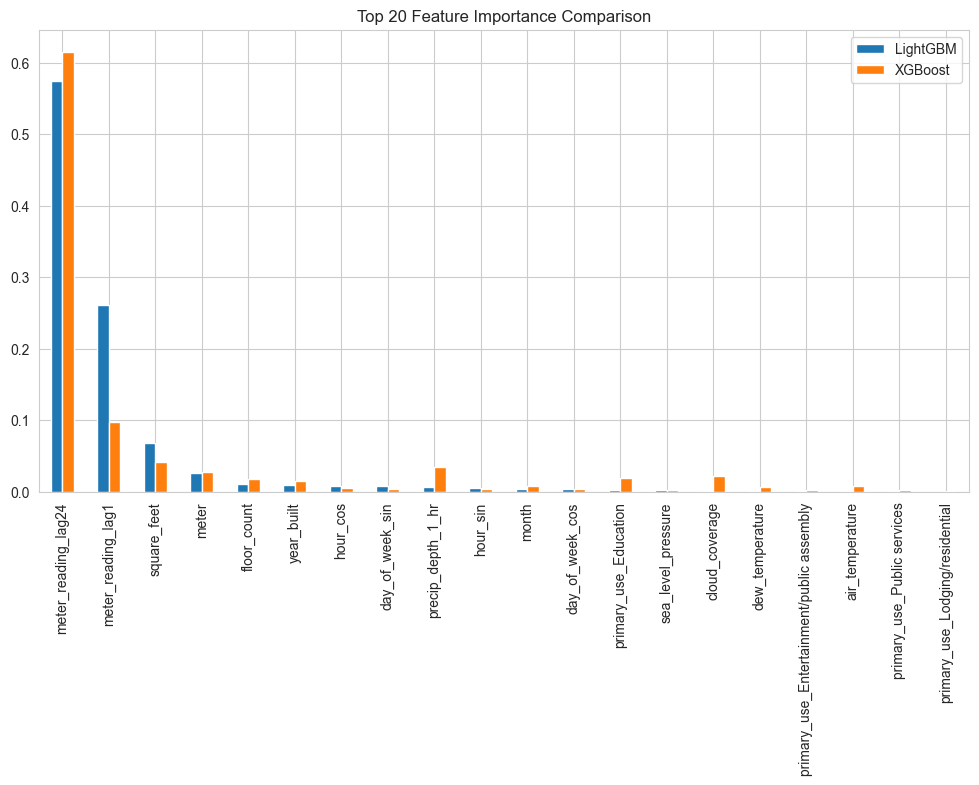

In [34]:
# LGBM importance (gain-based already used)
lgb_importance = model_lgb.feature_importance(importance_type='gain')

# XGB importance
xgb_importance = xgb_model.feature_importances_

feat_imp_df = pd.DataFrame({
    "LightGBM": lgb_importance,
    "XGBoost": xgb_importance
}, index=X_train.columns)

# Normalize (IMPORTANT)
feat_imp_df = feat_imp_df / feat_imp_df.sum()

# Plot top 20 only (otherwise messy)
feat_imp_df.sort_values("LightGBM", ascending=False).head(20).plot(
    kind="bar", figsize=(12,6)
)

plt.title("Top 20 Feature Importance Comparison")
plt.show()

In [35]:
correlation = feat_imp_df.corr()

print("\nFeature Importance Correlation:")
print(correlation)


Feature Importance Correlation:
          LightGBM   XGBoost
LightGBM  1.000000  0.957535
XGBoost   0.957535  1.000000
